In [2]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M

# setting initial parameter, wind and wave conditions
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
master_nodes_length = len(master_nodes)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\wind_stduy\BM10_direaction180_full200.nc"))
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_55_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_55_STIF1.mtx' 
wind_speeds = np.linspace(1, 50, 100) # 风速从1到50米/秒取30个点
wind_direction = 180 # 风向角
Hs = 4  #Hs = np.array([1., 2., 3., 4., 5., 6.])
                #Tp = np.array([4.57, 6.46, 7.91, 9.13, 10.21, 11.18])
Tp = 9.13
distance = 30 # 模块之间的距离
F_wave_coifficient = 0 # 系数1代表考虑，0代表不考虑
F_wind_coifficient = 1
F_wind_damping = 1
stiffness_value = 1e5
df = 0.01 # frequency resolution
use_hydrostatic = True # select hydrostatic stiffness type(bem or fem)
use_mooring = True # select mooring stiffness type(bem or fem) 
change_E = 0.01# 改变结构刚度，1代表不变，10代表10倍

# 主要计算程序
def create_mooring_stiffness_matrix(stiffness_value):
    # 创建一个总的刚度矩阵，维度为 (total_nodes*6, total_nodes*6)
    total_nodes = 793
    total_dof = total_nodes * 5
    global_stiffness_matrix = np.zeros((total_dof, total_dof))
    
    # 确定四个角点的节点编号
    node1 = 1
    node2 = 61
    node3 = 733
    node4 = 793
    
    # 四个系泊点的节点列表
    mooring_nodes = [node1, node2, node3, node4]
    
    # 定义6x6的局部刚度矩阵
    local_stiffness_matrix = np.zeros((5, 5))
    local_stiffness_matrix[0, 0] = stiffness_value  # x方向刚度
    local_stiffness_matrix[1, 1] = stiffness_value  # y方向刚度
    
    # 将局部刚度矩阵插入到总的刚度矩阵中
    for node in mooring_nodes:
        start_index = (node - 1) * 5
        for i in range(5):  # 只处理前5个自由度
            for j in range(5):
                global_stiffness_matrix[start_index + i, start_index + j] = local_stiffness_matrix[i, j]
    
    return global_stiffness_matrix

omega = dataset.omega.values
omega_number = np.arange(0,199,1)
# 引入波浪谱
import wave_spectrum as ws
S_wave = ws.jonswap(Hs, Tp, omega)

# 引入风载荷
import DM_Windload as DM_Wind

displacement_results = []  # 用于存储每个风速下 mean_displacement[20] 的结果

for wind_speed in wind_speeds:
    windload_cd_file = f"E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cd_degree{wind_direction}.txt"
    windload_cl_file = f"E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cl_degree{wind_direction}.txt"
    windload_cd = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cd_file,wind_direction = wind_direction)
    windload_cl = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cl_file,wind_direction = wind_direction)
    windload_cd_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cd_file,wind_direction = wind_direction)
    windload_cl_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cl_file,wind_direction = wind_direction)
    # 计算风产生的阻尼效应feng
    Wind_Damping = (windload_cd_damping.compute_wind_damping(dof=0) + 
                    windload_cl_damping.compute_wind_damping(dof=2) + 
                    windload_cd_damping.compute_wind_damping(dof=4))*5.9 # 5.9是转化系数多节点到少节点
    Wind_Damping = SEREP.reduce_dofs(Wind_Damping,num_nodes,[5])
    # 形成集中风载荷
    cd_sums,cd_submodules = windload_cd.wind_coefficient_lumped()
    cl_sums,cl_submodules = windload_cl.wind_coefficient_lumped()
    Area = 5*5
    nodes_per_row = 61

    # read mass and stiffness matrix
    M = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)

    # reduce dofs
    M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])

    if use_mooring:
        k = SEREP.reduce_dofs(k, num_nodes, [5])*change_E + create_mooring_stiffness_matrix(stiffness_value)
    else:
        k = SEREP.reduce_dofs(k, num_nodes, [5])

    # transform mass matrix, beta=0 is consistant mass matrix
    M = SEREP.transform_mass_matrix(M_consistant,beta=0)
    # obtaine master dofs and slave dofs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    # reduce matrix use SEREP
    # MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
    # reduce matrix use static condensation
    MR,KR,T = SEREP.static_condensation(k, M, MasterDofs, SlaveDofs)
    # node displacement
    displacement = []
    for i in omega_number:
        # wind load    omega
        wind_load = windload_cd.wind_force_lumped(target_frequency=omega[i],distance=distance,cd_sums=cd_sums,cl_sums=cl_sums,cl_submodules=cl_submodules)
        # read hydrodynamic data
        added_mass = dataset['added_mass'][i].values
        radiation_damping = dataset['radiation_damping'][i].values
        inertia_matrix = dataset['inertia_matrix'].values
        F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values
        # consider wave spectrum
        F_w = F_w * np.sqrt(S_wave[i]*df)
        # REDUCE THE MATRICES
        inertia_matrix = SEREP.reduce_dofs(inertia_matrix,master_nodes_length,[5])
        added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
        radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
        # hyrostatic stiffness or fem spring stiffness
        if use_hydrostatic:
            hydrostatic_stiffness = SEREP.reduce_dofs(dataset['hydrostatic_stiffness'].values, 10, [5])
            stiffness = hydrostatic_stiffness + KR
        else:
            total_nodes = 793
            nodes_per_row = 61
            area = 5 * 5
            k_fem = SEREP.get_fem_spring_stiffness(total_nodes, nodes_per_row, area)
            k_fem = SEREP.reduce_dofs(k_fem, num_nodes, [5])
            stiffness = T.T@k_fem@T + KR

        F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5).reshape(1,5*master_nodes_length)

        # Generate the system matrices
        mass = added_mass + MR
        damping = radiation_damping + T.T@Wind_Damping@T * F_wind_damping
        total_force = F_w * F_wave_coifficient + wind_load * F_wind_coifficient
        # Solve in frequency domain
        master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, total_force, omega[i])
        # Restore global displacement under disorder masterdofs and slavedofs
        global_displacement_disorder = T @ master_displacement
        master_displacement = master_displacement.reshape(10,5)[::-1].reshape(50,1)
        # Reorder global displacement under order
        global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
        # find the error, which is the difference between the master_displacement and the global_displacement of master positions,
        global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)

        displacement.append(global_displacement_replace)

    displacement_1 = np.array(displacement).reshape(199,793,5)
    interest_dof = 0
    displacement = displacement_1[:,:,interest_dof]

    displacement_results.append(displacement)  # 保存 mean_displacement[20] 的结果
#mean_displacement = np.mean(abs(displacement.reshape(199,793)), axis=1)
#mean_displacement[63]


KeyboardInterrupt: 

In [11]:
np.save("displacement_results001",displacement_results)

In [3]:
displacement_results = np.load("E:\phd\Code\DM-FEM2D\FEM_Reduce\windandwave2_paper\displacement_results001.npy")

In [4]:
displacement_results = np.array(displacement_results)

In [5]:
mean_displacement = np.mean(abs(displacement_results.reshape(100,199,793)), axis=2)

In [6]:
# 论文出图
import scienceplots
plt.style.use(['science','no-latex','ieee'])

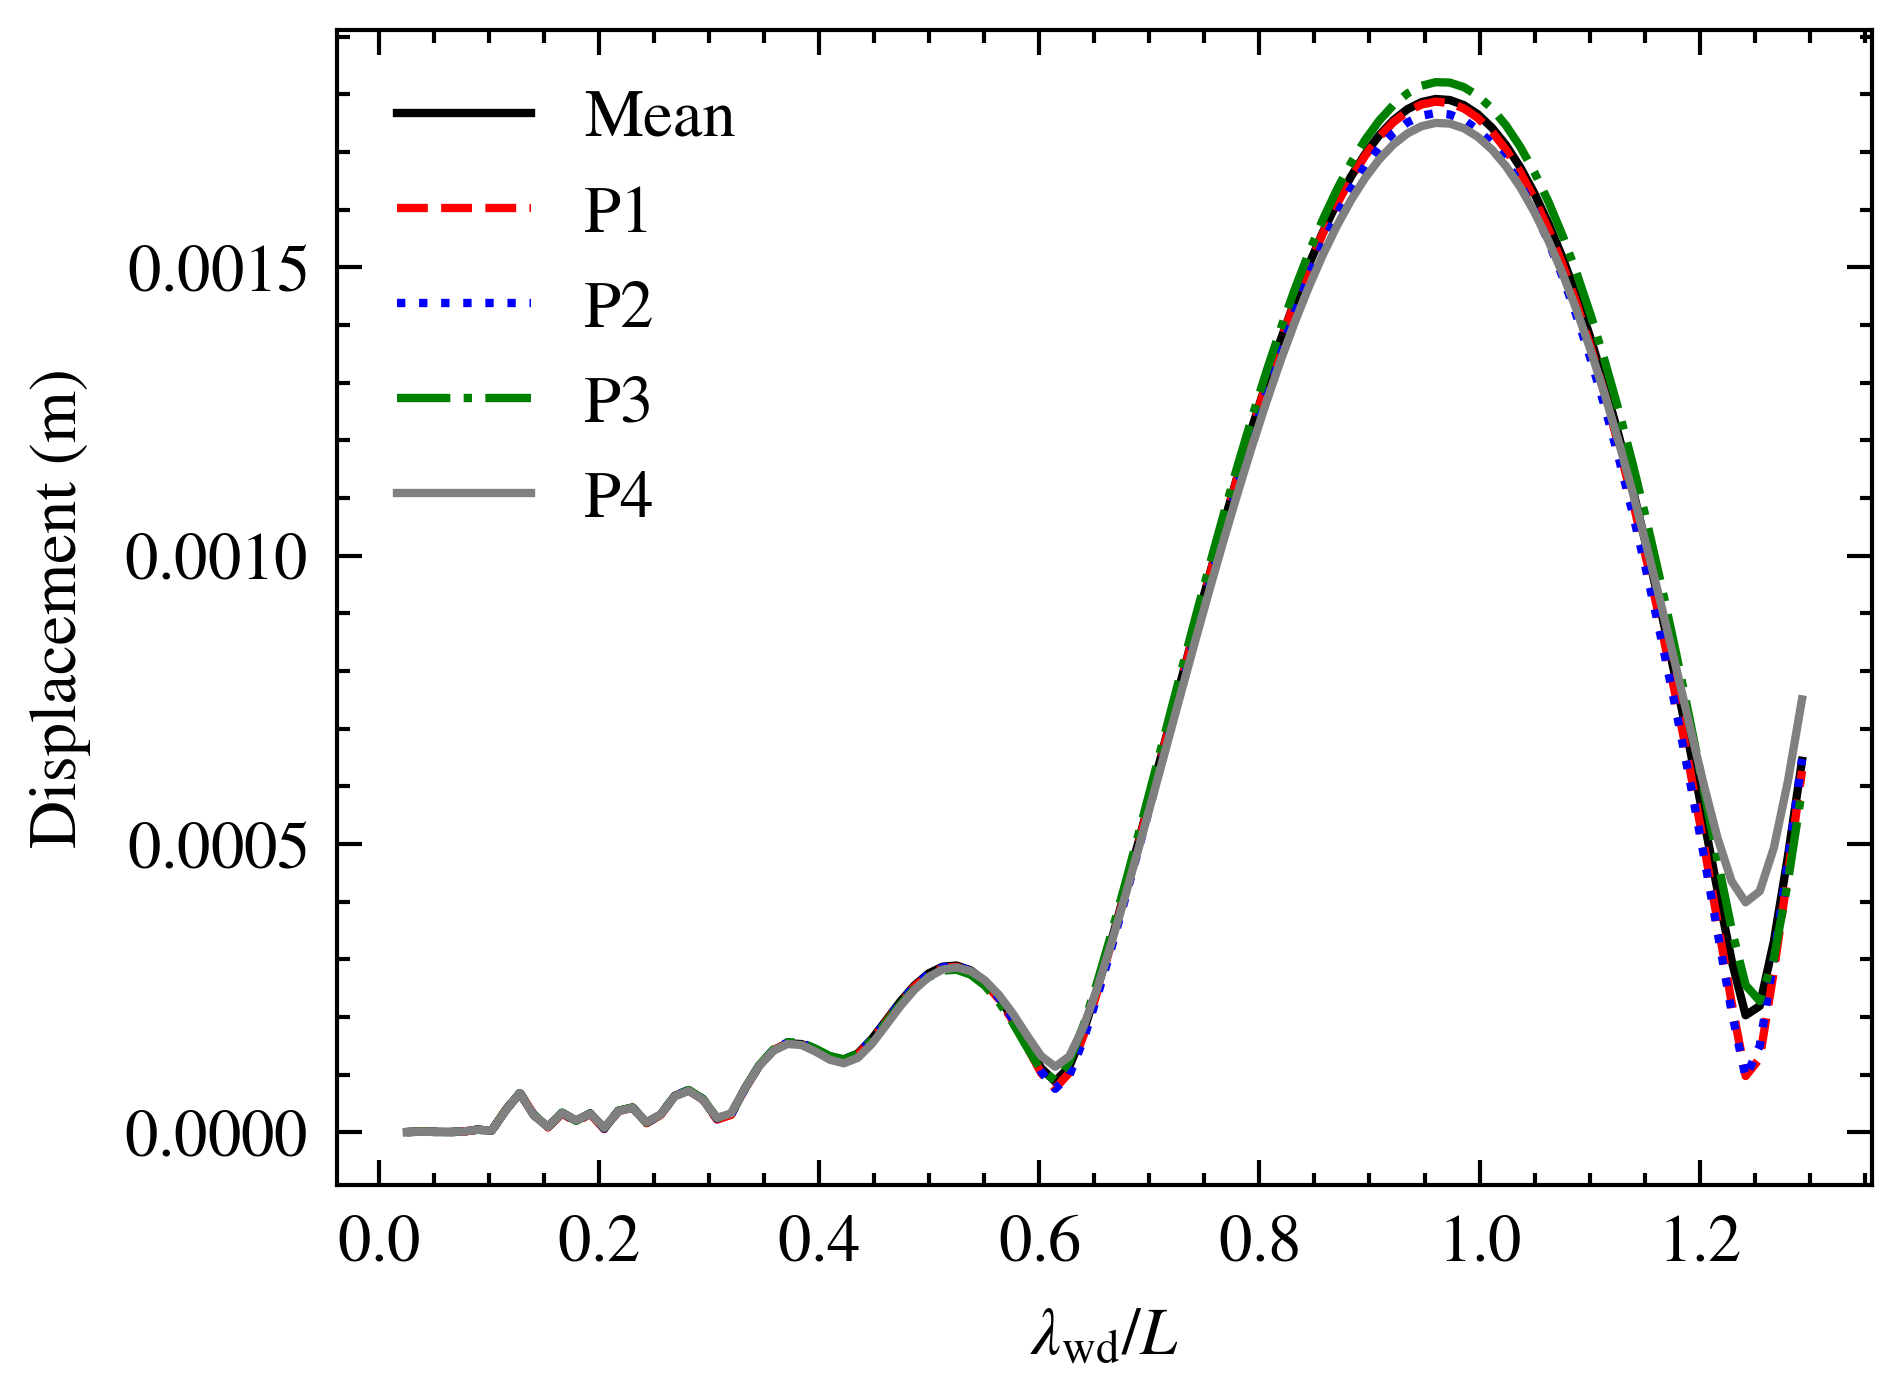

In [22]:
# 绘制每个风速对应的 mean_displacement[20]
i = 80
mean_displacement_results = np.array(mean_displacement)
plt.plot(wind_speeds*(2*np.pi/omega[i])/300, mean_displacement_results[:,i],label = "Mean")#, marker='o'
plt.plot(wind_speeds*(2*np.pi/omega[i])/300, np.abs(displacement_results.reshape(100,199,13,61)[:,i,6,0]), label= "P1")
plt.plot(wind_speeds*(2*np.pi/omega[i])/300, np.abs(displacement_results.reshape(100,199,13,61)[:,i,6,20]), label= "P2")
plt.plot(wind_speeds*(2*np.pi/omega[i])/300, np.abs(displacement_results.reshape(100,199,13,61)[:,i,6,40]), label= "P3")
plt.plot(wind_speeds*(2*np.pi/omega[i])/300, np.abs(displacement_results.reshape(100,199,13,61)[:,i,6,60]), color = "gray", label= "P4")


plt.xlabel(r'$\lambda_\mathrm{wd} / L$')  # 使用 \mathrm 表示 wd 为正体
plt.ylabel('Displacement (m)')
plt.legend()
plt.savefig(f"windlength{i}.pdf", format='pdf', dpi=300, bbox_inches='tight')
# plt.title('Mean Displacement [20] vs Wind Speed')
plt.show()

In [ ]:
plt.plot(mean_displacement_results[20,:]) # 3 / 9 
plt.yscale('log')

In [ ]:
mean_displacement_results[20,9]

In [ ]:
plt.plot(mean_displacement/0.01)

In [ ]:
mean_displacement[63]/0.01

In [ ]:
# 找到谷值点
from scipy.signal import find_peaks
mean_displacement_array = np.array(mean_displacement_results[:,120])/0.01
valley_indices, _ = find_peaks(-mean_displacement_array)
print("Valley points (indices):", valley_indices)


In [ ]:
wind_speeds[71]

In [ ]:
(2*np.pi/omega[120])*36.14

In [ ]:
wind_speeds[37]

In [ ]:
wind_speeds[24]

In [ ]:
wind_speeds[17]

In [ ]:
omega[63]